In [1]:
# Cell 1: Imports
import cv2
import torch
import numpy as np
import os
import glob
from pathlib import Path
import matplotlib.pyplot as plt
from torchvision import transforms
import time
import torch.nn as nn
import timm
from scipy.ndimage import gaussian_filter1d


d:\D-Documents\Self-Improvement\Python\Computer_Vision\Speed Estimation\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# save video

In [2]:

# Cell 2: Model Definition
class EfficientNetV2TinyModel(nn.Module):
    def __init__(self, pretrained=True, dropout_rate=0.1):
        super(EfficientNetV2TinyModel, self).__init__()
        
        self.base_model = timm.create_model('efficientnetv2_rw_t', pretrained=pretrained, num_classes=0)
        num_features = self.base_model.num_features
        
        self.head = nn.Sequential(
            nn.Dropout(dropout_rate),
            nn.Linear(num_features, 1),
        )
        
    def forward(self, x):
        features = self.base_model(x)
        output = self.head(features)
        return output


In [3]:
# Cell 3: Core Utility Functions
def load_model(model_path, device):
    """Load the trained speed estimation model."""
    model = EfficientNetV2TinyModel(pretrained=False, dropout_rate=0.2).to(device)
    model.load_state_dict(torch.load(model_path, map_location=device))
    model.eval()
    return model

def extract_forward_velocity(oxts_file_path):
    """Extract forward velocity (vf) from OXTS data file."""
    try:
        with open(oxts_file_path, 'r') as f:
            data = f.readline().strip().split()
            forward_velocity = float(data[8])  # vf is at index 8
            return forward_velocity
    except (FileNotFoundError, IndexError, ValueError) as e:
        print(f"Error reading {oxts_file_path}: {e}")
        return 0.0

def preprocess_image_for_flow(img1, img2, flow_model, model_name='dpflow'):
    """Preprocess two images to generate optical flow."""
    import ptlflow
    from ptlflow.utils import flow_utils
    
    device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
    
    if model_name == 'dpflow':
        # Preprocess images
        img1 = cv2.convertScaleAbs(img1, alpha=1.5, beta=0)
        img2 = cv2.convertScaleAbs(img2, alpha=1.5, beta=0)
        
        # Convert to tensor
        imgs = np.stack([img1, img2], axis=0)
        imgs = torch.from_numpy(imgs).permute(0, 3, 1, 2).float().unsqueeze(0).to(device)
        
        # Generate optical flow
        with torch.no_grad():
            pred = flow_model({"images": imgs})
        flow = pred['flows'][0, 0].cpu()
        
        # Convert flow to RGB
        flow_rgb = flow_utils.flow_to_rgb(flow, background='dark').permute(1, 2, 0).numpy()
        flow_rgb = cv2.resize(flow_rgb, (224, 224))
        
        return flow_rgb
        
    elif model_name == 'fastflownet':
        from ptlflow.utils.io_adapter import IOAdapter
        
        # FastFlowNet expects RGB and padding handled via IOAdapter
        img1 = cv2.cvtColor(img1, cv2.COLOR_BGR2RGB)
        img2 = cv2.cvtColor(img2, cv2.COLOR_BGR2RGB)
        
        img1 = cv2.convertScaleAbs(img1, alpha=1.5, beta=0)
        img2 = cv2.convertScaleAbs(img2, alpha=1.5, beta=0)

        io_adapter = IOAdapter(flow_model, img1.shape[:2])
        inputs = io_adapter.prepare_inputs([img1, img2])
        
        inputs = {k: v.to(device) if isinstance(v, torch.Tensor) else v for k, v in inputs.items()}
        
        with torch.no_grad():
            pred = flow_model(inputs)
            
        pred = io_adapter.unscale(pred)
        flow = pred['flows'][0, 0].cpu()
        
        flow_rgb = flow_utils.flow_to_rgb(flow, background='dark').permute(1, 2, 0).numpy()
        return flow_rgb


def save_video_with_text(frames, output_path, fps=10):
    """Save frames as video."""
    height, width, _ = frames[0].shape
    fourcc = cv2.VideoWriter_fourcc(*'XVID')
    out = cv2.VideoWriter(output_path, fourcc, fps, (width, height))
    for frame in frames:
        out.write(frame)
    out.release()
    print(f"Saved video to {output_path}")


In [4]:

# Cell 4: Smoothing Functions
def apply_ema_smoothing(predicted_speed, ema_speed, alpha=0.3):
    """Single-step EMA smoothing."""
    return alpha * predicted_speed + (1 - alpha) * ema_speed

def apply_gaussian_smoothing(speeds, sigma=1.0):
    """Apply Gaussian smoothing to speed array."""
    if len(speeds) < 2:
        return speeds
    smoothed = gaussian_filter1d(speeds, sigma=sigma)
    return smoothed.tolist()

def apply_ema_gaussian_smoothing(speeds, alpha=0.3, sigma=1.0):
    """Apply EMA followed by Gaussian smoothing."""
    if len(speeds) < 2:
        return speeds
    
    # Apply EMA
    ema_speeds = []
    ema_speed = 0.0
    for speed in speeds:
        ema_speed = alpha * speed + (1 - alpha) * ema_speed
        ema_speeds.append(ema_speed)
    
    # Apply Gaussian smoothing if sigma > 0
    if sigma > 0:
        smoothed = gaussian_filter1d(ema_speeds, sigma=sigma)
        return smoothed.tolist()
    return ema_speeds

def apply_threshold_ema_smoothing(speeds, alpha=0.3, threshold=2.0):
    """
    Apply EMA smoothing only to small fluctuations.
    Large changes (above threshold) are preserved.
    """
    if len(speeds) < 2:
        return speeds
    
    smoothed_speeds = [speeds[0]]
    ema_speed = speeds[0]
    
    for i in range(1, len(speeds)):
        speed_change = abs(speeds[i] - smoothed_speeds[-1])
        
        if speed_change > threshold:
            # Large change - use raw speed
            smoothed_speeds.append(speeds[i])
            ema_speed = speeds[i]
        else:
            # Small change - apply EMA smoothing
            ema_speed = alpha * speeds[i] + (1 - alpha) * ema_speed
            smoothed_speeds.append(ema_speed)
    
    return smoothed_speeds

def apply_adaptive_smoothing(speeds, alpha=0.3, threshold=2.0, sigma=1.0):
    """Adaptive smoothing: threshold EMA + Gaussian."""
    if len(speeds) < 2:
        return speeds
    
    # Step 1: Apply threshold-based EMA
    ema_smoothed = apply_threshold_ema_smoothing(speeds, alpha=alpha, threshold=threshold)
    
    # Step 2: Apply light Gaussian smoothing
    final_smoothed = gaussian_filter1d(ema_smoothed, sigma=sigma)
    
    return final_smoothed.tolist()


In [5]:


# Cell 5: Plotting Functions
def plot_speed_predictions(speeds, frame_indices, output_path=None):
    """Plot predicted speeds over frames."""
    plt.figure(figsize=(14, 6))
    
    plt.plot(frame_indices, speeds, 'b-', linewidth=2, label='Predicted Speed')
    plt.scatter(frame_indices, speeds, c='blue', s=30, alpha=0.6)
    
    plt.xlabel('Frame Index', fontsize=12)
    plt.ylabel('Speed (m/s)', fontsize=12)
    plt.title('Predicted Speed Over Frames', fontsize=14, fontweight='bold')
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    
    if output_path:
        plt.savefig(output_path, dpi=300, bbox_inches='tight')
        print(f"Plot saved to: {output_path}")
    
    plt.show()

def plot_speed_comparison(gt_speeds, predicted_speeds, frame_indices, output_path=None):
    """Plot ground truth vs predicted speeds."""
    plt.figure(figsize=(14, 6))
    
    plt.plot(frame_indices, gt_speeds, 'g-', linewidth=2, label='Ground Truth Speed', alpha=0.7)
    plt.plot(frame_indices, predicted_speeds, 'b-', linewidth=2, label='Predicted Speed', alpha=0.7)
    
    plt.scatter(frame_indices, gt_speeds, c='green', s=30, alpha=0.5)
    plt.scatter(frame_indices, predicted_speeds, c='blue', s=30, alpha=0.5)
    
    plt.xlabel('Frame Index', fontsize=12)
    plt.ylabel('Speed (m/s)', fontsize=12)
    plt.title('Ground Truth vs Predicted Speed Over Frames', fontsize=14, fontweight='bold')
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    
    if output_path:
        plt.savefig(output_path, dpi=300, bbox_inches='tight')
        print(f"Comparison plot saved to: {output_path}")
    
    plt.show()

def save_speeds_to_file(speeds, gt_speeds, frame_indices, image_files, output_path):
    """Save predicted speeds to a text file."""
    with open(output_path, 'w') as f:
        f.write("Frame_Index,Frame_Name,Ground_Truth_Speed_m/s,Predicted_Speed_m/s,Error_m/s\n")
        for i, (idx, speed, gt_speed) in enumerate(zip(frame_indices, speeds, gt_speeds)):
            if idx < len(image_files):
                frame_name = os.path.basename(image_files[idx])
            else:
                frame_name = f"frame_{idx}"
            error = abs(gt_speed - speed)
            f.write(f"{idx},{frame_name},{gt_speed:.6f},{speed:.6f},{error:.6f}\n")
    
    print(f"Results saved to: {output_path}")


In [6]:
# Cell 6: Main Evaluation Function
def evaluate_kitti_folder_with_plots(drive_folder_path, model_path, max_frames=50, 
                                     save_video=True, save_plots=True, save_results=True, 
                                     smoothing_type='threshold_ema', alpha=0.3, threshold=2.0, sigma=0.5,
                                     flow_model_name='dpflow'):
    """
    Enhanced evaluation function with multiple smoothing options.
    
    Args:
        drive_folder_path (str): Path to the image folder
        model_path (str): Path to the model
        max_frames (int): Maximum frames to process
        save_video (bool): Whether to save video
        save_plots (bool): Whether to save plots
        save_results (bool): Whether to save results to file
        smoothing_type (str): Type of smoothing - 'none', 'gaussian', 'ema', 'threshold_ema', 'adaptive'
        alpha (float): Alpha for EMA smoothing (0.1-0.7)
        threshold (float): Threshold for threshold_ema/adaptive (m/s)
        sigma (float): Sigma for Gaussian smoothing
        flow_model_name (str): Name of optical flow model ('dpflow' or 'fastflownet')
    """
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Using device: {device}")
    print(f"Smoothing type: {smoothing_type}")
    print(f"Optical flow model: {flow_model_name}")
    
    # Load speed estimation model
    model = load_model(model_path, device)
    
    # Load optical flow model
    import ptlflow
    flow_model = ptlflow.get_model(flow_model_name, ckpt_path='kitti').to(device)
    flow_model.eval()
    
    # Transform for model input
    transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Resize((224, 224)),
    ])
    
    # Use the provided path directly as the image folder
    image_03_data_path = drive_folder_path
    
    # Navigate up two levels to get to the drive folder, then to oxts/data
    parent_dir = os.path.dirname(os.path.dirname(drive_folder_path))
    oxts_data_path = os.path.join(parent_dir, "oxts", "data")
    
    # Check if required folders exist
    print(f"\nProcessing image folder: {image_03_data_path}")
    print(f"Looking for oxts at: {oxts_data_path}\n")
    
    if not os.path.exists(image_03_data_path):
        print(f"Error: Image folder not found at {image_03_data_path}")
        return [], [], []
    if not os.path.exists(oxts_data_path):
        print(f"Error: oxts/data folder not found at {oxts_data_path}")
        return [], [], []
    
    # Get all image files and sort them
    image_files = glob.glob(os.path.join(image_03_data_path, "*.png"))
    image_files.sort()
    
    if len(image_files) < 2:
        print(f"Error: Need at least 2 images for optical flow")
        return [], [], []
    
    print(f"Found {len(image_files)} frames")

    video_frames = []
    raw_predicted_speeds = []
    gt_speeds = []
    frame_indices = []

    error_sum = 0.0
    
    # Process frames
    for i in range(min(len(image_files) - 1, max_frames)):
        # Load consecutive images
        img1_path = image_files[i]
        img2_path = image_files[i + 1]
        
        img1 = cv2.imread(img1_path)
        img2 = cv2.imread(img2_path)
        
        if img1 is None or img2 is None:
            continue
        
        # Extract frame numbers for OXTS lookup
        frame1_num = os.path.splitext(os.path.basename(img1_path))[0]
        frame2_num = os.path.splitext(os.path.basename(img2_path))[0]
        
        # Get ground truth velocity for frame 2
        oxts_file = os.path.join(oxts_data_path, f"{frame2_num}.txt")
        gt_velocity = extract_forward_velocity(oxts_file)
        
        try:
            # Generate optical flow
            flow_rgb = preprocess_image_for_flow(img1, img2, flow_model, flow_model_name)
            
            # Prepare flow for model
            flow_tensor = transform(flow_rgb).unsqueeze(0).to(device)
            
            # Predict speed
            with torch.no_grad():
                predicted_speed = model(flow_tensor).cpu().item()

            # Apply speed adjustments
            if flow_model_name == 'dpflow':
                predicted_speed = max(0.0, predicted_speed + 1.0)
            else:
                predicted_speed = max(0.0, predicted_speed) # assuming we don't need the +1 adjustment for fastflownet

            # Store RAW predicted speed (no smoothing yet)
            raw_predicted_speeds.append(predicted_speed)
            gt_speeds.append(gt_velocity)
            frame_indices.append(i + 1)
            
            # Display results (using raw speed for now)
            display_frame = img2.copy()
            
            # Resize for display
            display_frame = cv2.resize(display_frame, (800, 600))
            flow_display = cv2.resize((flow_rgb * 255).astype(np.uint8), (400, 300))
            
            cv2.putText(display_frame, f"Frame: {i+1}/{min(len(image_files)-1, max_frames)}", 
                       (10, 30), cv2.FONT_HERSHEY_SIMPLEX, 0.8, (0, 255, 0), 2)
            cv2.putText(display_frame, f"GT Speed: {gt_velocity:.2f} m/s", 
                       (10, 70), cv2.FONT_HERSHEY_SIMPLEX, 0.8, (0, 255, 0), 2)
            cv2.putText(display_frame, f"Predicted: {predicted_speed:.2f} m/s", 
                       (10, 110), cv2.FONT_HERSHEY_SIMPLEX, 0.8, (255, 0, 0), 2)
            cv2.putText(display_frame, f"Error: {abs(gt_velocity - predicted_speed):.2f} m/s", 
                       (10, 150), cv2.FONT_HERSHEY_SIMPLEX, 0.8, (0, 0, 255), 2)
            
            if save_video:
                video_frames.append(display_frame.copy())
                
        except Exception as e:
            print(f"Error processing frame {i}: {e}")
            continue
    
    cv2.destroyAllWindows()

    # Apply smoothing AFTER collecting all raw speeds
    print(f"Applying {smoothing_type} smoothing...")
    
    if smoothing_type == 'none':
        predicted_speeds = raw_predicted_speeds
    elif smoothing_type == 'gaussian':
        predicted_speeds = apply_gaussian_smoothing(raw_predicted_speeds, sigma=sigma)
    elif smoothing_type == 'ema':
        predicted_speeds = apply_ema_gaussian_smoothing(raw_predicted_speeds, alpha=alpha, sigma=0)
    elif smoothing_type == 'threshold_ema':
        predicted_speeds = apply_threshold_ema_smoothing(raw_predicted_speeds, alpha=alpha, threshold=threshold)
    elif smoothing_type == 'adaptive':
        predicted_speeds = apply_adaptive_smoothing(raw_predicted_speeds, alpha=alpha, threshold=threshold, sigma=sigma)
    else:
        print(f"Warning: Unknown smoothing type '{smoothing_type}', using raw speeds")
        predicted_speeds = raw_predicted_speeds

    # Recalculate error with smoothed speeds
    error_sum = sum(abs(gt - pred) for gt, pred in zip(gt_speeds, predicted_speeds))

    # Save video
    if save_video and video_frames:
        save_video_with_text(video_frames, f"output_speed_estimation_{flow_model_name}.avi", fps=10)
    
    # Display statistics
    print("\nEvaluation completed!")
    print(f"Smoothing method: {smoothing_type}")
    print(f"Total Error Sum: {error_sum:.2f}")
    if predicted_speeds:
        print(f"\nSpeed Statistics:")
        print(f"  Mean GT speed: {np.mean(gt_speeds):.4f} m/s")
        print(f"  Mean predicted speed: {np.mean(predicted_speeds):.4f} m/s")
        print(f"  Std predicted speed: {np.std(predicted_speeds):.4f} m/s")
        print(f"  Min predicted speed: {np.min(predicted_speeds):.4f} m/s")
        print(f"  Max predicted speed: {np.max(predicted_speeds):.4f} m/s")
        print(f"  Mean Absolute Error: {error_sum / len(predicted_speeds):.4f} m/s")
    
    # Save results to file
    if save_results and predicted_speeds:
        output_file = f"predicted_speeds_{smoothing_type}_{flow_model_name}.txt"
        save_speeds_to_file(predicted_speeds, gt_speeds, frame_indices, image_files, output_file)
    
    # Create plots
    if save_plots and predicted_speeds:
        plot_speed_predictions(
            speeds=predicted_speeds,
            frame_indices=frame_indices,
            output_path=f"predicted_speeds_{smoothing_type}_{flow_model_name}_plot.png"
        )
        
        plot_speed_comparison(
            gt_speeds=gt_speeds,
            predicted_speeds=predicted_speeds,
            frame_indices=frame_indices,
            output_path=f"speed_comparison_{smoothing_type}_{flow_model_name}_plot.png"
        )
    
    return predicted_speeds, gt_speeds, frame_indices

# Cell 7: Clean vs Noise Comparison Function
def plot_clean_vs_noise_speeds_(clean_path, noise_path, model_path, max_frames=1000, 
                                smoothing_type='threshold_ema', alpha=0.3, threshold=2.0, sigma=0.5,
                                flow_model_name='dpflow'):
    """
    Run evaluations for clean and noise datasets, then plot their predicted speeds.
    
    Args:
        clean_path (str): Path to the data_cleaned folder
        noise_path (str): Path to the data_noise folder
        model_path (str): Path to the model
        max_frames (int): Maximum frames to process
        smoothing_type (str): Type of smoothing to apply
        alpha (float): Alpha for EMA smoothing
        threshold (float): Threshold for threshold_ema/adaptive
        sigma (float): Sigma for Gaussian/adaptive smoothing
        flow_model_name (str): Name of optical flow model ('dpflow' or 'fastflownet')
    """
    # Run evaluation for clean data
    print("Evaluating clean data...")
    clean_speeds, _, clean_indices = evaluate_kitti_folder_with_plots(
        clean_path, model_path, max_frames=max_frames, save_video=False, save_plots=False, 
        save_results=False, smoothing_type=smoothing_type, alpha=alpha, threshold=threshold, sigma=sigma,
        flow_model_name=flow_model_name
    )
    
    # Run evaluation for noise data
    print("\nEvaluating noise data...")
    noise_speeds, _, noise_indices = evaluate_kitti_folder_with_plots(
        noise_path, model_path, max_frames=max_frames, save_video=False, save_plots=False, 
        save_results=False, smoothing_type=smoothing_type, alpha=alpha, threshold=threshold, sigma=sigma,
        flow_model_name=flow_model_name
    )
    
    # Check if we have data
    if not clean_speeds or not noise_speeds:
        print("No data to plot.")
        return
    
    # Plot both lines
    plt.figure(figsize=(14, 6))
    
    plt.plot(clean_indices, clean_speeds, 'g-', linewidth=2, label='Clean Data Predicted Speed')
    plt.plot(noise_indices, noise_speeds, 'b-', linewidth=2, label='Noise Data Predicted Speed')
    
    # Highlight the first frame (no prediction)
    plt.axvspan(0, 1, color='red', alpha=0.3, label='No Prediction (Frame 0)')
    
    plt.xlabel('Frame Index', fontsize=12)
    plt.ylabel('Predicted Speed (m/s)', fontsize=12)
    plt.title(f'Predicted Speeds: Clean vs Noise Data ({smoothing_type} smoothing, {flow_model_name})', 
              fontsize=14, fontweight='bold')
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    
    # Save the plot
    output_filename = f"clean_vs_noise_speeds_{smoothing_type}_{flow_model_name}_plot.png"
    plt.savefig(output_filename, dpi=300, bbox_inches='tight')
    print(f"Plot saved to: {output_filename}")
    
    plt.show()

def plot_clean_vs_noise_speeds(clean_path, noise_path, model_path, max_frames=1000, 
                                smoothing_type='threshold_ema', alpha=0.3, threshold=2.0, sigma=0.5,
                                flow_model_name='dpflow'):
    """
    Run evaluations for clean and noise datasets, then plot their predicted speeds.
    
    Args:
        clean_path (str): Path to the data_cleaned folder
        noise_path (str): Path to the data_noise folder
        model_path (str): Path to the model
        max_frames (int): Maximum frames to process
        smoothing_type (str): Type of smoothing to apply
        alpha (float): Alpha for EMA smoothing
        threshold (float): Threshold for threshold_ema/adaptive
        sigma (float): Sigma for Gaussian/adaptive smoothing
        flow_model_name (str): Name of optical flow model ('dpflow' or 'fastflownet')
    """
    # Run evaluation for clean data
    print("Evaluating clean data...")
    clean_speeds, _, clean_indices = evaluate_kitti_folder_with_plots(
        clean_path, model_path, max_frames=max_frames, save_video=False, save_plots=False, 
        save_results=False, smoothing_type=smoothing_type, alpha=alpha, threshold=threshold, sigma=sigma,
        flow_model_name=flow_model_name
    )
    
    # Run evaluation for noise data
    print("\nEvaluating noise data...")
    noise_speeds, _, noise_indices = evaluate_kitti_folder_with_plots(
        noise_path, model_path, max_frames=max_frames, save_video=False, save_plots=False, 
        save_results=False, smoothing_type=smoothing_type, alpha=alpha, threshold=threshold, sigma=sigma,
        flow_model_name=flow_model_name
    )
    
    # Check if we have data
    if not clean_speeds or not noise_speeds:
        print("No data to plot.")
        return
    
    # Plot both lines with larger figure size
    plt.figure(figsize=(16, 10))
    
    plt.plot(clean_indices, clean_speeds, 'g-', linewidth=2, label='Clean Data Predicted Speed')
    plt.plot(noise_indices, noise_speeds, 'b-', linewidth=2, label='Noise Data Predicted Speed')
    
    # Highlight the first frame (no prediction)
    plt.axvspan(0, 1, color='red', alpha=0.3, label='No Prediction (Frame 0)')
    
    # Set y-axis limits to provide more vertical space
    all_speeds = clean_speeds + noise_speeds
    y_min = min(all_speeds) - 2  # Add padding below
    y_max = max(all_speeds) + 5  # Add more padding above
    plt.ylim(y_min, y_max)
    
    plt.xlabel('Frame Index', fontsize=14)
    plt.ylabel('Predicted Speed (m/s)', fontsize=14)
    plt.title(f'Predicted Speeds: Clean vs Noise Data ({smoothing_type} smoothing, {flow_model_name})', 
              fontsize=16, fontweight='bold')
    plt.grid(True, alpha=0.3)
    plt.legend(fontsize=12)
    plt.tight_layout()
    
    # Save the plot
    output_filename = f"clean_vs_noise_speeds_{smoothing_type}_{flow_model_name}_plot.png"
    plt.savefig(output_filename, dpi=300, bbox_inches='tight')
    print(f"Plot saved to: {output_filename}")
    
    plt.show()


Train\2011_09_26_drive_0029_sync
\Val\2011_09_26_drive_0101_sync\


Evaluating clean data...
Using device: cuda
Smoothing type: threshold_ema
Optical flow model: dpflow


d:\D-Documents\Self-Improvement\Python\Computer_Vision\Speed Estimation\venv\Lib\site-packages\timm\models\layers\__init__.py:48: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)


[!!alt_cuda_corr is not compiled!!]


2026-03-31 08:00:54.562 | INFO     | ptlflow.models.dpflow.dpflow:__init__:158 - DPFlow: --model.pyramid_levels is not set, the number of pyramid levels will be inferred from the input size.
2026-03-31 08:00:54.736 | INFO     | ptlflow:restore_model:283 - Restored model state from checkpoint: kitti



Processing image folder: D:\D-Documents\Self-Improvement\Python\Computer_Vision\Speed Estimation\Speed_Estimation_Cleaned\Dataset\Kitti\Raw_Data\Unzipped\Train\2011_09_26_drive_0029_sync\2011_09_26\2011_09_26_drive_0029_sync\image_03\data_cleaned
Looking for oxts at: D:\D-Documents\Self-Improvement\Python\Computer_Vision\Speed Estimation\Speed_Estimation_Cleaned\Dataset\Kitti\Raw_Data\Unzipped\Train\2011_09_26_drive_0029_sync\2011_09_26\2011_09_26_drive_0029_sync\oxts\data

Found 27 frames


2026-03-31 08:00:54.975 | INFO     | ptlflow.models.dpflow.dpflow:forward_flow:366 - DPFlow: Detected change in input size. The number of pyramid levels will change to 3, corresponding to output stride 32.


Applying threshold_ema smoothing...

Evaluation completed!
Smoothing method: threshold_ema
Total Error Sum: 21.71

Speed Statistics:
  Mean GT speed: 16.0744 m/s
  Mean predicted speed: 15.5398 m/s
  Std predicted speed: 0.7816 m/s
  Min predicted speed: 14.3907 m/s
  Max predicted speed: 16.7824 m/s
  Mean Absolute Error: 0.8350 m/s

Evaluating noise data...
Using device: cuda
Smoothing type: threshold_ema
Optical flow model: dpflow


2026-03-31 08:01:00.368 | INFO     | ptlflow.models.dpflow.dpflow:__init__:158 - DPFlow: --model.pyramid_levels is not set, the number of pyramid levels will be inferred from the input size.
2026-03-31 08:01:00.529 | INFO     | ptlflow:restore_model:283 - Restored model state from checkpoint: kitti
2026-03-31 08:01:00.577 | INFO     | ptlflow.models.dpflow.dpflow:forward_flow:366 - DPFlow: Detected change in input size. The number of pyramid levels will change to 3, corresponding to output stride 32.



Processing image folder: D:\D-Documents\Self-Improvement\Python\Computer_Vision\Speed Estimation\Speed_Estimation_Cleaned\Dataset\Kitti\Raw_Data\Unzipped\Train\2011_09_26_drive_0029_sync\2011_09_26\2011_09_26_drive_0029_sync\image_03\data_blurr
Looking for oxts at: D:\D-Documents\Self-Improvement\Python\Computer_Vision\Speed Estimation\Speed_Estimation_Cleaned\Dataset\Kitti\Raw_Data\Unzipped\Train\2011_09_26_drive_0029_sync\2011_09_26\2011_09_26_drive_0029_sync\oxts\data

Found 27 frames
Error processing frame 5: all input arrays must have the same shape
Error processing frame 6: all input arrays must have the same shape
Error processing frame 7: all input arrays must have the same shape
Error processing frame 8: all input arrays must have the same shape
Error processing frame 9: all input arrays must have the same shape
Applying threshold_ema smoothing...

Evaluation completed!
Smoothing method: threshold_ema
Total Error Sum: 14.42

Speed Statistics:
  Mean GT speed: 16.0826 m/s
  Me

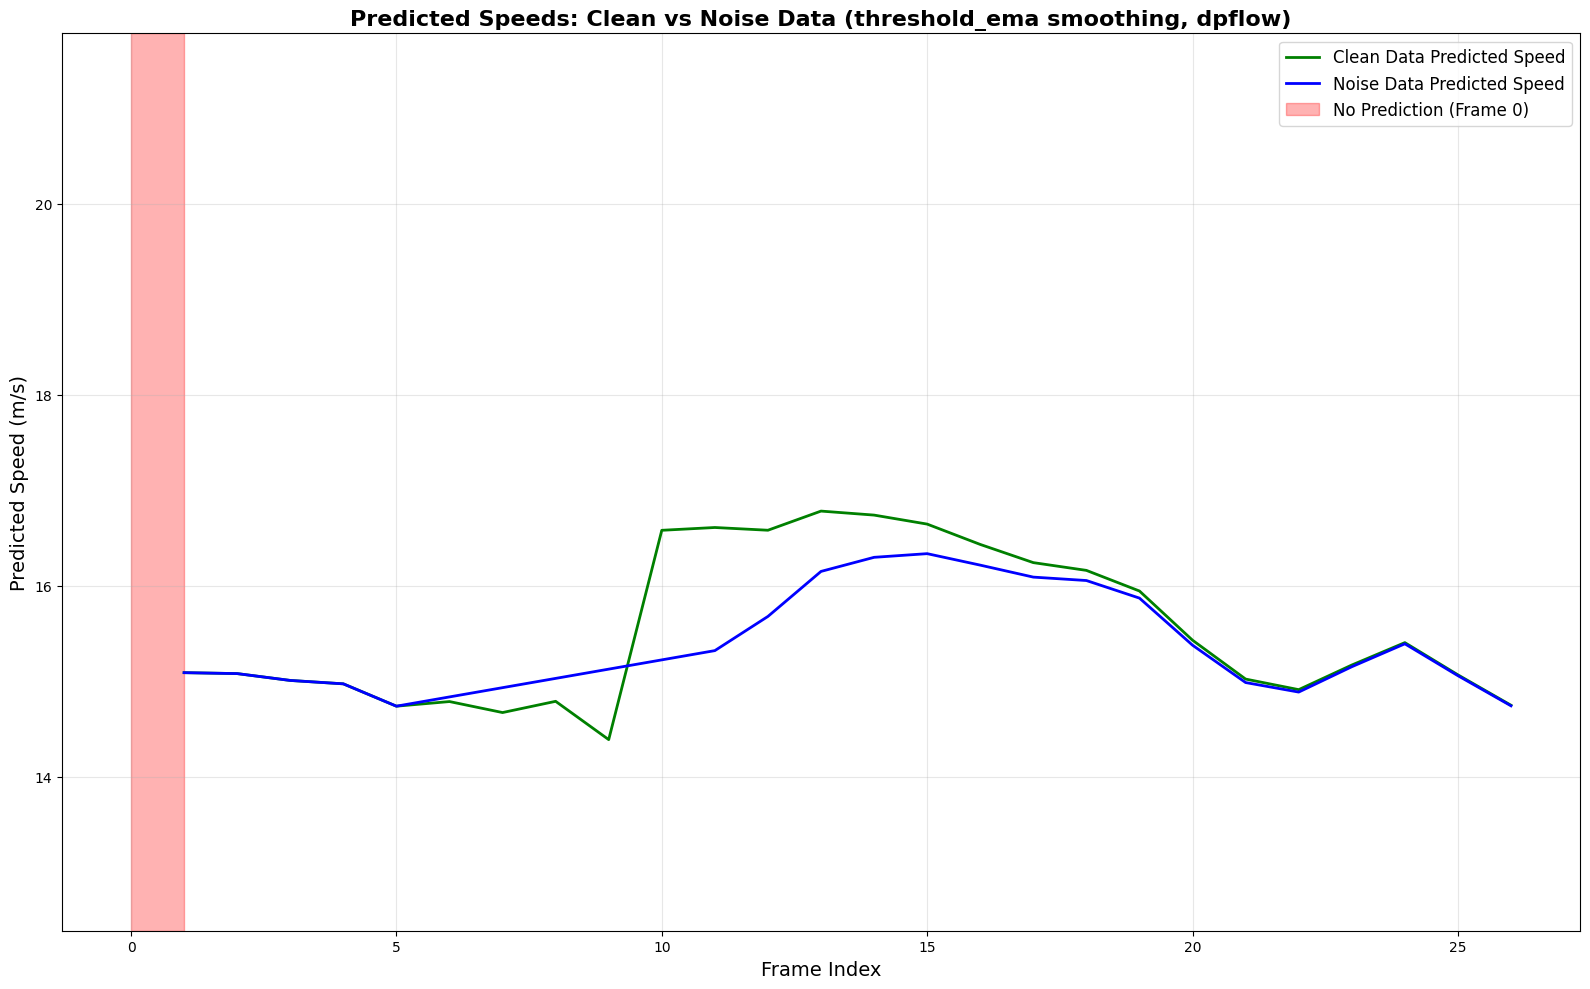

In [7]:
# Cell 8: Example Usage
# Paths
clean_path = r"D:\D-Documents\Self-Improvement\Python\Computer_Vision\Speed Estimation\Speed_Estimation_Cleaned\Dataset\Kitti\Raw_Data\Unzipped\Train\2011_09_26_drive_0029_sync\2011_09_26\2011_09_26_drive_0029_sync\image_03\data_cleaned"
noise_path = r"D:\D-Documents\Self-Improvement\Python\Computer_Vision\Speed Estimation\Speed_Estimation_Cleaned\Dataset\Kitti\Raw_Data\Unzipped\Train\2011_09_26_drive_0029_sync\2011_09_26\2011_09_26_drive_0029_sync\image_03\data_blurr"

# Set the flow model to use ('dpflow' or 'fastflownet')
flow_model_name = 'dpflow'

# Path to the directory containing '<model_name>_best.pth'
weights_dir = r"D:\D-Documents\Self-Improvement\Python\Computer_Vision\Speed Estimation\Speed_Estimation_FYP_Cleaned\Speed_Estimation_Module_Lucentra\weights"
model_path = os.path.join(weights_dir, f"{flow_model_name}_best.pth")

# Test different smoothing methods
plot_clean_vs_noise_speeds(clean_path, noise_path, model_path, 
                           smoothing_type='threshold_ema', 
                           alpha=0.3, 
                           threshold=2.0,
                           max_frames=1000,
                           flow_model_name=flow_model_name)
